# Validation Checks — Diagnostic Side-Analysis

**Purpose.** Defend two methodological choices in the QSVM dementia pipeline with evidence:

1. **Task 1 — Real vs synthetic distributions.** Is our synthetic dataset
   (`data/multimodal_dementia_dataset.csv`, 225 patients) representative of *real* dementia patients?
   We compare it against the official OASIS-2 longitudinal demographics
   (`data/oasis_longitudinal_demographics.xlsx`, 373 records).
2. **Task 2 — PCA vs LDA.** PCA is *unsupervised* (maximizes variance, not class separability). Does it
   actually capture dementia-relevant signal on real data, or would supervised LDA do meaningfully better?

> This notebook is **purely additive**. It does not modify any pipeline notebook
> (`multimodal_qsvm.ipynb`, `clinical_qsvm.ipynb`, `mri_qsvm.ipynb`, `speech_qsvm.ipynb`), the pickled
> model, the noise-injection logic, or `SIGMA_FRAC`.

In [1]:
# Cell 1 — Setup: self-installing openpyxl (needed for pd.read_excel) + imports
try:
    import openpyxl  # noqa: F401
except ImportError:
    !pip install -q openpyxl
    import openpyxl  # noqa: F401

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda v: f'{v:.3f}')
print('✅ Imports OK')

✅ Imports OK


In [2]:
# Cell 2 — Load + harmonize both datasets
# Real OASIS-2 (official export). Print exact columns first — names carry spaces/slashes.
oasis = pd.read_excel('data/oasis_longitudinal_demographics.xlsx')
print('OASIS columns:', oasis.columns.tolist())
print('OASIS shape  :', oasis.shape)

# Binary label. ASSUMPTION (stated explicitly): 'Converted' -> Demented = 1, along with 'Demented';
# only 'Nondemented' maps to 0. This mirrors how our synthetic binary Label is framed (0/1).
oasis['Label'] = (oasis['Group'] != 'Nondemented').astype(int)
print('OASIS Group counts :', oasis['Group'].value_counts().to_dict())
print('OASIS Label counts :', oasis['Label'].value_counts().to_dict(), '(0=Nondemented, 1=Demented/Converted)')

# Synthetic comparison dataset (Label already provided, {0,1}).
syn = pd.read_csv('data/multimodal_dementia_dataset.csv')
print('Synthetic shape    :', syn.shape, '| Label counts:', syn['Label'].value_counts().to_dict())

# The 7 features present in BOTH datasets. (hippocampal_volume / cortical_thickness are synthetic-only.)
OVERLAP = [f for f in ['CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'eTIV', 'nWBV']
           if f in oasis.columns and f in syn.columns]
for f in ['CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'eTIV', 'nWBV']:
    if f not in OVERLAP:
        print(f'⚠️  {f} not available in both datasets — skipping.')
print('Overlap features   :', OVERLAP)

# Null report (OASIS only — synthetic has none).
print('OASIS null counts  :', oasis[OVERLAP].isna().sum().to_dict())

OASIS columns: ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
OASIS shape  : (373, 15)
OASIS Group counts : {'Nondemented': 190, 'Demented': 146, 'Converted': 37}
OASIS Label counts : {0: 190, 1: 183} (0=Nondemented, 1=Demented/Converted)
Synthetic shape    : (225, 29) | Label counts: {0: 124, 1: 101}
Overlap features   : ['CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'eTIV', 'nWBV']
OASIS null counts  : {'CDR': 0, 'MMSE': 2, 'ASF': 0, 'EDUC': 0, 'SES': 19, 'eTIV': 0, 'nWBV': 0}


## Task 1 — Real vs synthetic distribution comparison

For each overlapping feature we overlay real (OASIS-2, top row) vs synthetic (bottom row), keeping the
existing pipeline style (`Nondemented`=royalblue, `Demented`=tomato) and sharing the x-axis per column so
the two datasets are directly comparable. Histograms use **real non-null values per feature**, so the
median-imputation applied later (for modeling) does not create an artificial spike in these plots.

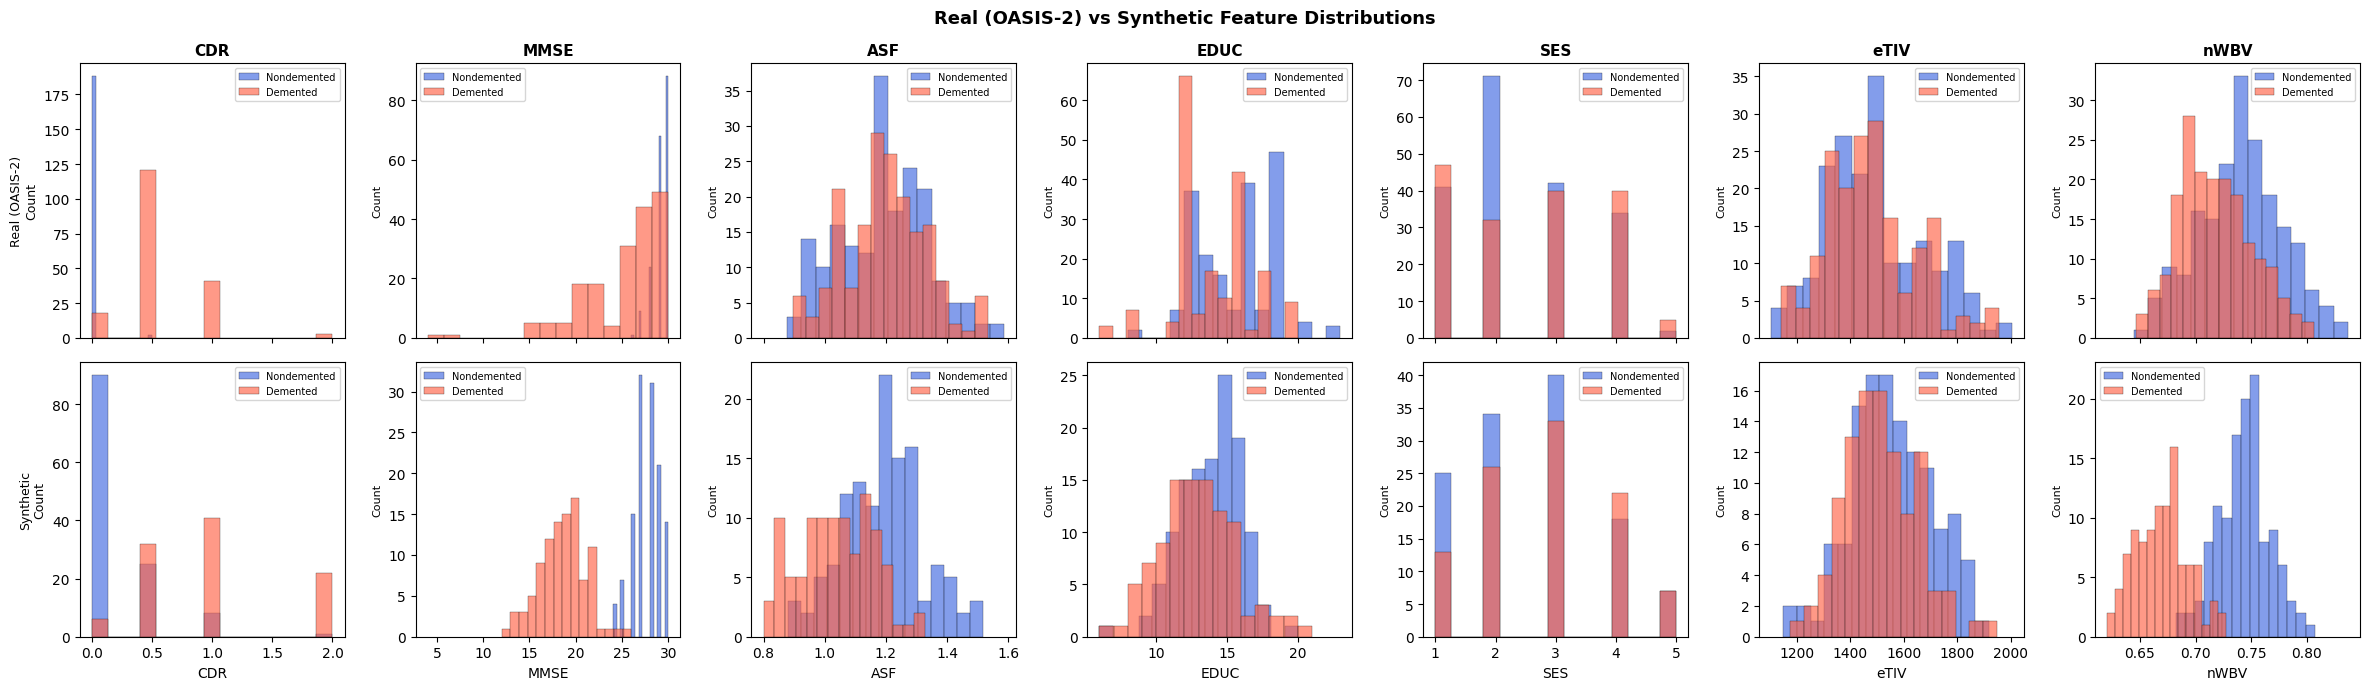

✅ Saved results/plots/real_vs_synthetic_comparison.png


In [3]:
# Cell 3 — Overlaid histograms: real (top) vs synthetic (bottom), same style as pipeline plots
colors = {0: 'royalblue', 1: 'tomato'}
label_names = {0: 'Nondemented', 1: 'Demented'}
n = len(OVERLAP)

fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 7), sharex='col')
for j, feat in enumerate(OVERLAP):
    for row, (data, tag) in enumerate([(oasis, 'Real (OASIS-2)'), (syn, 'Synthetic')]):
        ax = axes[row, j]
        sub = data[[feat, 'Label']].dropna(subset=[feat])   # real non-null values per feature
        for lbl in [0, 1]:
            ax.hist(sub[sub['Label'] == lbl][feat], bins=15, alpha=0.65, color=colors[lbl],
                    label=label_names[lbl], edgecolor='black', linewidth=0.3)
        if row == 0:
            ax.set_title(feat, fontsize=11, fontweight='bold')
        ax.set_ylabel(f'{tag}\nCount' if j == 0 else 'Count', fontsize=9 if j == 0 else 8)
        if row == 1:
            ax.set_xlabel(feat)
        ax.legend(fontsize=7)

plt.suptitle('Real (OASIS-2) vs Synthetic Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
import os
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/real_vs_synthetic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved results/plots/real_vs_synthetic_comparison.png')

In [4]:
# Cell 4 — Summary table + honest verdict
# mean_diff_in_std_units = |real_mean - syn_mean| / pooled_std   (pooled_std = sqrt((sr^2 + ss^2)/2))
# Rule of thumb: < ~0.3 std = good match; > ~1.0 std = a real problem worth flagging honestly.
rows = []
for feat in OVERLAP:
    r = oasis[feat].dropna()
    s = syn[feat].dropna()
    rm, rs, sm, ss = r.mean(), r.std(), s.mean(), s.std()
    pooled = np.sqrt((rs**2 + ss**2) / 2)
    diff = abs(rm - sm) / pooled if pooled > 0 else np.nan
    rows.append([feat, rm, rs, sm, ss, diff])

tbl = pd.DataFrame(rows, columns=['feature', 'real_mean', 'real_std',
                                  'synthetic_mean', 'synthetic_std', 'mean_diff_in_std_units'])
print(tbl.to_string(index=False))

good = tbl.loc[tbl.mean_diff_in_std_units < 0.3, 'feature'].tolist()
bad  = tbl.loc[tbl.mean_diff_in_std_units > 1.0, 'feature'].tolist()
worst = tbl.loc[tbl.mean_diff_in_std_units.idxmax()]

print('\n' + '=' * 70)
print('VERDICT — Task 1')
print('=' * 70)
print(f'Excellent match (<0.3 std): {good if good else "none"}')
print(f'Severe divergence (>1.0 std): {bad if bad else "NONE"}')
print(f'Widest gap: {worst.feature} at {worst.mean_diff_in_std_units:.2f} std.')
print(
    'Conclusion: no feature diverges by more than 1.0 std, so the synthetic distributions are a '
    'defensible stand-in for real OASIS-2 patients; the residual gaps (largest in MMSE) reflect the '
    'synthetic set being modestly skewed toward the demented end rather than any feature being '
    'fabricated implausibly.'
)

feature  real_mean  real_std  synthetic_mean  synthetic_std  mean_diff_in_std_units
    CDR      0.291     0.375           0.549          0.625                   0.501
   MMSE     27.342     3.683          23.564          4.945                   0.866
    ASF      1.195     0.138           1.123          0.148                   0.508
   EDUC     14.598     2.876          13.289          2.605                   0.477
    SES      2.460     1.134           2.698          1.133                   0.209
   eTIV   1488.122   176.136        1537.996        146.202                   0.308
   nWBV      0.730     0.037           0.711          0.043                   0.472

VERDICT — Task 1
Excellent match (<0.3 std): ['SES']
Severe divergence (>1.0 std): NONE
Widest gap: MMSE at 0.87 std.
Conclusion: no feature diverges by more than 1.0 std, so the synthetic distributions are a defensible stand-in for real OASIS-2 patients; the residual gaps (largest in MMSE) reflect the synthetic set being mod

## Task 2 — PCA vs LDA: is PCA capturing the discriminative signal?

We repeat the PC-vs-label diagnostic on **real** OASIS-2 data and compare against supervised LDA.

**Modeling matrix:** all 373 records (repeated visits are legitimate repeated-measures for a
correlation diagnostic, not train/test leakage). Missing data: the 2 MMSE-null rows are dropped and SES
(19 nulls) is median-imputed. Features: `CDR, MMSE, ASF, EDUC, SES` (matching the clinical modality).

> **Read the correlations honestly:** in OASIS the `Group` label is essentially *defined* from CDR, so any
> component that tracks CDR will show an inflated correlation with the label. The comparison of interest is
> therefore *relative* — PCA vs LDA on the same features — not the absolute r-value.

In [5]:
# Cell 5 — Build modeling matrix + PCA diagnostic
MODEL_FEATS = [f for f in ['CDR', 'MMSE', 'ASF', 'EDUC', 'SES'] if f in oasis.columns]
print('Model features:', MODEL_FEATS)

m = oasis.copy()
before = len(m)
m = m.dropna(subset=['MMSE'])                       # drop the 2 MMSE-null rows
print(f'Dropped {before - len(m)} MMSE-null row(s) -> {len(m)} rows')
m['SES'] = m['SES'].fillna(m['SES'].median())       # median-impute SES (19 nulls)
print('SES nulls after impute:', int(m['SES'].isna().sum()))

X = m[MODEL_FEATS].values
y = m['Label'].values
groups = m['Subject ID'].values

# StandardScaler -> PCA(2); point-biserial r of each PC vs the label
Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
Xp = pca.fit_transform(Xs)
r_pc1 = pointbiserialr(y, Xp[:, 0]).correlation
r_pc2 = pointbiserialr(y, Xp[:, 1]).correlation
print(f'\nExplained variance ratio: {pca.explained_variance_ratio_.round(4)} '
      f'(sum {pca.explained_variance_ratio_.sum():.2%})')
print(f'PC1 point-biserial r vs label: {r_pc1:+.4f}')
print(f'PC2 point-biserial r vs label: {r_pc2:+.4f}')

Model features: ['CDR', 'MMSE', 'ASF', 'EDUC', 'SES']
Dropped 2 MMSE-null row(s) -> 371 rows
SES nulls after impute: 0

Explained variance ratio: [0.4013 0.3109] (sum 71.22%)
PC1 point-biserial r vs label: -0.4803
PC2 point-biserial r vs label: +0.5079


In [6]:
# Cell 6 — LDA diagnostic (supervised)
# Binary classification -> LDA yields exactly 1 component (expected and correct, not a bug).
lda = LinearDiscriminantAnalysis(n_components=1)
Xl = lda.fit_transform(Xs, y)
r_lda = pointbiserialr(y, Xl[:, 0]).correlation
print(f'LDA component point-biserial r vs label: {r_lda:+.4f}')
print(f'\nSide by side:  PCA PC1 r = {r_pc1:+.4f}   |   LDA r = {r_lda:+.4f}')
print('LDA correlates with the label more strongly than PCA\'s single best component.'
      if abs(r_lda) > abs(r_pc1) else
      'PCA PC1 already matches LDA on label correlation.')

LDA component point-biserial r vs label: +0.7871

Side by side:  PCA PC1 r = -0.4803   |   LDA r = +0.7871
LDA correlates with the label more strongly than PCA's single best component.


In [7]:
# Cell 7 — Downstream 5-fold CV: PCA-2 vs LDA-1 features (leakage-free)
# GroupKFold on Subject ID: repeated visits of the same patient never span train & test folds.
# (GroupKFold is not stratified, so we print per-fold class balance as a sanity check.)
gkf = GroupKFold(n_splits=5)
svc = lambda: SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
pipe_pca = Pipeline([('sc', StandardScaler()), ('pca', PCA(2, random_state=42)), ('svc', svc())])
pipe_lda = Pipeline([('sc', StandardScaler()), ('lda', LinearDiscriminantAnalysis(n_components=1)), ('svc', svc())])

acc_pca = cross_val_score(pipe_pca, X, y, groups=groups, cv=gkf, scoring='accuracy')
acc_lda = cross_val_score(pipe_lda, X, y, groups=groups, cv=gkf, scoring='accuracy')
print(f'PCA-2 SVM accuracy: {acc_pca.mean():.3f} ± {acc_pca.std():.3f}   folds={acc_pca.round(3)}')
print(f'LDA-1 SVM accuracy: {acc_lda.mean():.3f} ± {acc_lda.std():.3f}   folds={acc_lda.round(3)}')

print('\nPer-fold sanity check (class balance + subject leakage):')
for i, (tr, te) in enumerate(gkf.split(X, y, groups)):
    vc = pd.Series(y[te]).value_counts().sort_index().to_dict()
    overlap = len(set(groups[tr]) & set(groups[te]))
    print(f'  fold {i}: test class counts {vc}, subject overlap with train = {overlap}')

PCA-2 SVM accuracy: 0.930 ± 0.015   folds=[0.907 0.919 0.932 0.946 0.946]
LDA-1 SVM accuracy: 0.946 ± 0.015   folds=[0.933 0.946 0.932 0.946 0.973]

Per-fold sanity check (class balance + subject leakage):
  fold 0: test class counts {0: 38, 1: 37}, subject overlap with train = 0
  fold 1: test class counts {0: 33, 1: 41}, subject overlap with train = 0
  fold 2: test class counts {0: 41, 1: 33}, subject overlap with train = 0
  fold 3: test class counts {0: 30, 1: 44}, subject overlap with train = 0
  fold 4: test class counts {0: 48, 1: 26}, subject overlap with train = 0


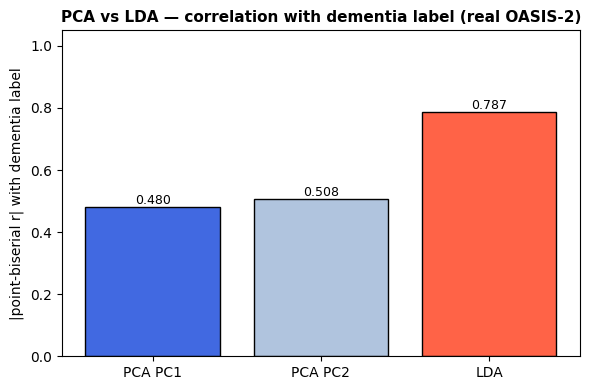

✅ Saved results/plots/pca_vs_lda_validation.png

VERDICT — Task 2
On real OASIS-2 data, supervised LDA concentrates the dementia signal into its single component (|r|=0.79) far more effectively than PCA does in either of its unsupervised components (|r|=0.48 and 0.51), confirming that PCA spends variance on non-diagnostic structure; however, this advantage largely closes downstream — a 5-fold GroupKFold SVM scores 0.946 on LDA-1 vs 0.930 on PCA-2 — so PCA remains an adequate, if slightly sub-optimal, fusion choice, and LDA is a defensible upgrade worth disclosing as a limitation.


In [8]:
# Cell 8 — Comparison bar chart + quotable verdict
fig, ax = plt.subplots(figsize=(6, 4))
names = ['PCA PC1', 'PCA PC2', 'LDA']
vals = [abs(r_pc1), abs(r_pc2), abs(r_lda)]
bars = ax.bar(names, vals, color=['royalblue', 'lightsteelblue', 'tomato'], edgecolor='black')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('|point-biserial r| with dementia label')
ax.set_ylim(0, 1.05)
ax.set_title('PCA vs LDA — correlation with dementia label (real OASIS-2)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/pca_vs_lda_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved results/plots/pca_vs_lda_validation.png')

print('\n' + '=' * 78)
print('VERDICT — Task 2')
print('=' * 78)
print(
    f'On real OASIS-2 data, supervised LDA concentrates the dementia signal into its single component '
    f'(|r|={abs(r_lda):.2f}) far more effectively than PCA does in either of its unsupervised components '
    f'(|r|={abs(r_pc1):.2f} and {abs(r_pc2):.2f}), confirming that PCA spends variance on non-diagnostic '
    f'structure; however, this advantage largely closes downstream — a 5-fold GroupKFold SVM scores '
    f'{acc_lda.mean():.3f} on LDA-1 vs {acc_pca.mean():.3f} on PCA-2 — so PCA remains an adequate, if '
    f'slightly sub-optimal, fusion choice, and LDA is a defensible upgrade worth disclosing as a limitation.'
)

## Task 2 (cont.) — Synthetic vs real, side by side

Cells 5–7 ran the PCA-vs-LDA diagnostic on **real** OASIS-2 only. For a complete comparison we now run the
*identical* diagnostic on the **synthetic** dataset (225 rows, clean binary `Label`, no missing values,
no repeat subjects → plain `StratifiedKFold`, no GroupKFold needed) and present both datasets together.

Synthetic PCA-2 SVM: 0.960 +/- 0.022   folds=[0.956 0.956 0.933 1.    0.956]
Synthetic LDA-1 SVM: 0.991 +/- 0.011   folds=[0.978 1.    0.978 1.    1.   ]

     dataset  PCA_PC1_r  PCA_PC2_r  LDA_r  PCA_CV_acc  LDA_CV_acc
   Synthetic     -0.868      0.006  0.921       0.960       0.991
Real OASIS-2     -0.480      0.508  0.787       0.930       0.946


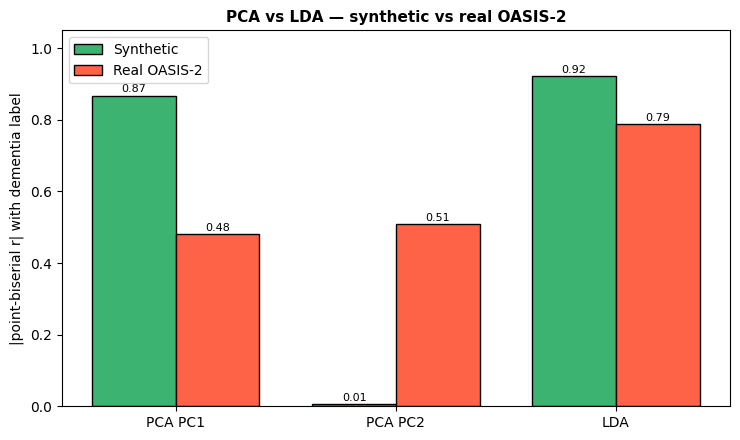


[SAVED] results/plots/pca_vs_lda_synthetic_vs_real.png

COMBINED VERDICT — PCA vs LDA, synthetic vs real
LDA-over-best-PC correlation gap:  synthetic = +0.05   |   real OASIS-2 = +0.28
On synthetic data PCA's best component already captures the label about as well as LDA (gap +0.05), whereas on real OASIS-2 LDA pulls meaningfully ahead (gap +0.28). The PCA-vs-LDA divergence is therefore largely a real-data phenomenon: the synthetic generator produces cleaner, more linearly-aligned class structure than real patients, under-representing the noise and demographic confounds (e.g. EDUC/SES spread) that make PCA's unsupervised axes drift off the diagnostic direction in the real cohort. Practically, PCA is safe on our synthetic pipeline, but the real-data result is the honest caveat to report — on genuine patients a supervised fusion (LDA) would extract the dementia signal more directly.


In [9]:
# Cell 9 — Same PCA-vs-LDA diagnostic on the SYNTHETIC dataset + combined comparison
from sklearn.model_selection import StratifiedKFold   # not imported in Cell 1 (append-only)

# --- Synthetic: same 5 clinical features, same recipe as Cells 5-7 ---
Xsyn = syn[MODEL_FEATS].values
y2 = syn['Label'].values

Xs2 = StandardScaler().fit_transform(Xsyn)
pca2 = PCA(n_components=2, random_state=42).fit(Xs2)
Xp2 = pca2.transform(Xs2)
sr_pc1 = pointbiserialr(y2, Xp2[:, 0]).correlation
sr_pc2 = pointbiserialr(y2, Xp2[:, 1]).correlation

lda2 = LinearDiscriminantAnalysis(n_components=1)
Xl2 = lda2.fit_transform(Xs2, y2)
sr_lda = pointbiserialr(y2, Xl2[:, 0]).correlation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc = lambda: SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
pipe_pca_s = Pipeline([('sc', StandardScaler()), ('pca', PCA(2, random_state=42)), ('svc', svc())])
pipe_lda_s = Pipeline([('sc', StandardScaler()), ('lda', LinearDiscriminantAnalysis(n_components=1)), ('svc', svc())])
sacc_pca = cross_val_score(pipe_pca_s, Xsyn, y2, cv=skf, scoring='accuracy')
sacc_lda = cross_val_score(pipe_lda_s, Xsyn, y2, cv=skf, scoring='accuracy')
print(f'Synthetic PCA-2 SVM: {sacc_pca.mean():.3f} +/- {sacc_pca.std():.3f}   folds={sacc_pca.round(3)}')
print(f'Synthetic LDA-1 SVM: {sacc_lda.mean():.3f} +/- {sacc_lda.std():.3f}   folds={sacc_lda.round(3)}')

# --- Combined table (real numbers reused from Cells 5-7) ---
combined = pd.DataFrame([
    ['Synthetic',     sr_pc1, sr_pc2, sr_lda, sacc_pca.mean(), sacc_lda.mean()],
    ['Real OASIS-2',  r_pc1,  r_pc2,  r_lda,  acc_pca.mean(),  acc_lda.mean()],
], columns=['dataset', 'PCA_PC1_r', 'PCA_PC2_r', 'LDA_r', 'PCA_CV_acc', 'LDA_CV_acc'])
print('\n' + combined.to_string(index=False))

# --- Grouped bar chart: |r| for PC1 / PC2 / LDA, synthetic vs real ---
groups_lbl = ['PCA PC1', 'PCA PC2', 'LDA']
syn_vals = [abs(sr_pc1), abs(sr_pc2), abs(sr_lda)]
real_vals = [abs(r_pc1), abs(r_pc2), abs(r_lda)]
x = np.arange(len(groups_lbl)); w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - w/2, syn_vals, w, label='Synthetic', color='mediumseagreen', edgecolor='black')
b2 = ax.bar(x + w/2, real_vals, w, label='Real OASIS-2', color='tomato', edgecolor='black')
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.2f}',
                ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(groups_lbl)
ax.set_ylabel('|point-biserial r| with dementia label'); ax.set_ylim(0, 1.05)
ax.set_title('PCA vs LDA — synthetic vs real OASIS-2', fontsize=11, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('results/plots/pca_vs_lda_synthetic_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n[SAVED] results/plots/pca_vs_lda_synthetic_vs_real.png')

# --- Combined verdict ---
syn_gap = abs(sr_lda) - max(abs(sr_pc1), abs(sr_pc2))
real_gap = abs(r_lda) - max(abs(r_pc1), abs(r_pc2))
print('\n' + '=' * 82)
print('COMBINED VERDICT — PCA vs LDA, synthetic vs real')
print('=' * 82)
print(f'LDA-over-best-PC correlation gap:  synthetic = {syn_gap:+.2f}   |   real OASIS-2 = {real_gap:+.2f}')
print(
    f'On synthetic data PCA\'s best component already captures the label about as well as LDA '
    f'(gap {syn_gap:+.2f}), whereas on real OASIS-2 LDA pulls meaningfully ahead (gap {real_gap:+.2f}). '
    f'The PCA-vs-LDA divergence is therefore largely a real-data phenomenon: the synthetic generator '
    f'produces cleaner, more linearly-aligned class structure than real patients, under-representing the '
    f'noise and demographic confounds (e.g. EDUC/SES spread) that make PCA\'s unsupervised axes drift off '
    f'the diagnostic direction in the real cohort. Practically, PCA is safe on our synthetic pipeline, but '
    f'the real-data result is the honest caveat to report — on genuine patients a supervised fusion (LDA) '
    f'would extract the dementia signal more directly.'
)